# **Pesquisa em largura**

## **1. Introdução - Grafos**

Um `grafo` é uma estrutura utilizada para modelar redes de relacionamentos e conexões entre elementos.

**Definição Técnica**: `Grafos` são estruturas matemáticas abstratas usadas para rrepresentar relações entre objetos. Eles consistem em um conjunto de `vértices`, que representam as entidades, conectados por `arestas`, que rrepresentam as conexões ou interações entre eles.

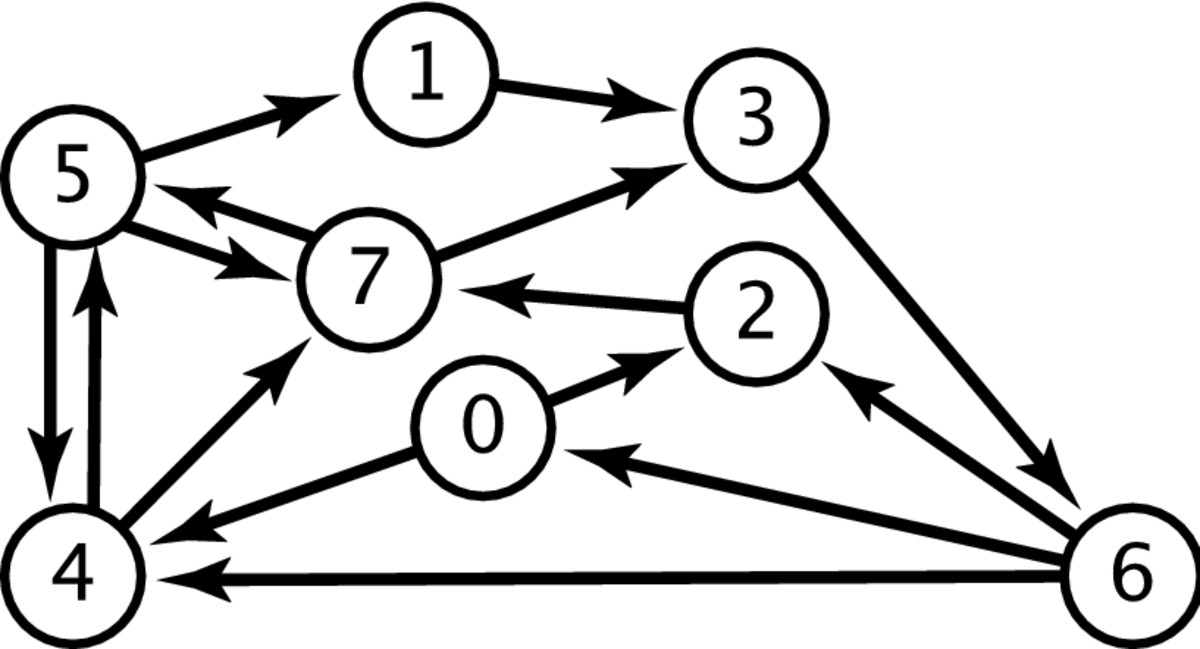

**Grafos Direcionados (Dígrafos)**: Possuem arestas com sentido definido, ou seja, a relação acontece apenas no sentido definido pela a aresta.

**Grafos Não-Direcionados**: Possuem conexões bidirecionais, ou seja, as arestas não têm sentido. Uma ligação entre A e B funciona nos dois sentidos.

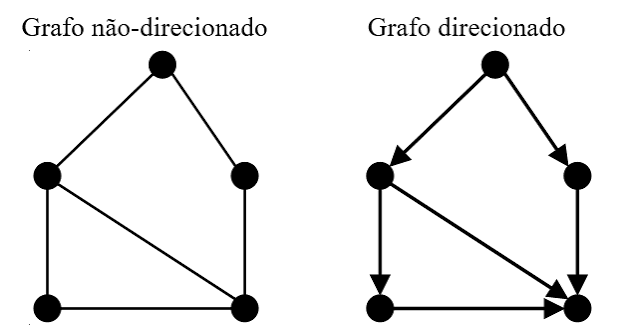

### **Implementação de grafos**

Um grafo é basicamente uma estrutura que modela relações. As `tabelas hash` podem ser utilizadas para representar um grafo, pois é possível expressar relações com ela.

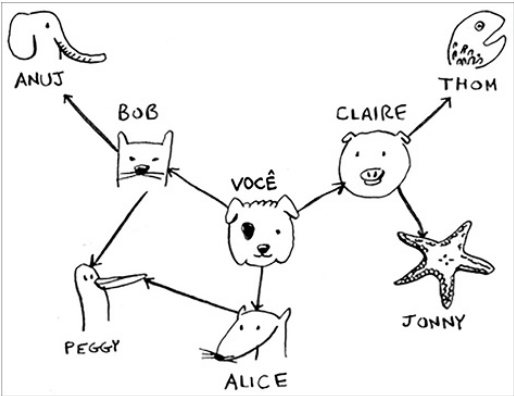

In [65]:
grafo = {}

grafo['guthy'] = ['alice', 'bob', 'claire']
grafo['bob'] = ['anuj', 'peggy']
grafo['claire'] = ['thom', 'jonny']
grafo['alice'] = ['peggy']
grafo['peggy'] = []
grafo['anuj'] = []
grafo['jonny'] = []
grafo['thom'] = []

for k, v in grafo.items():

    print(f"{k} está conectado com: {v}")

guthy está conectado com: ['alice', 'bob', 'claire']
bob está conectado com: ['anuj', 'peggy']
claire está conectado com: ['thom', 'jonny']
alice está conectado com: ['peggy']
peggy está conectado com: []
anuj está conectado com: []
jonny está conectado com: []
thom está conectado com: []


## **Filas**

Uma `fila` (queue) é uma estrutura de dados que organiza os elementos seguingo a política `FIFO` (first in, first out).
Isso significa que o primeiro elemento a entrar é sempre o primeiro a sair.

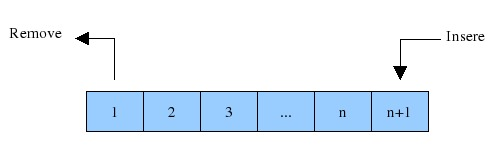

As principais operações são `enqueue` (inserir) e `dequeue` (remover).

- Filas são FIFO (first in, first out)

- Pilhas são LIFO (last in, first out)

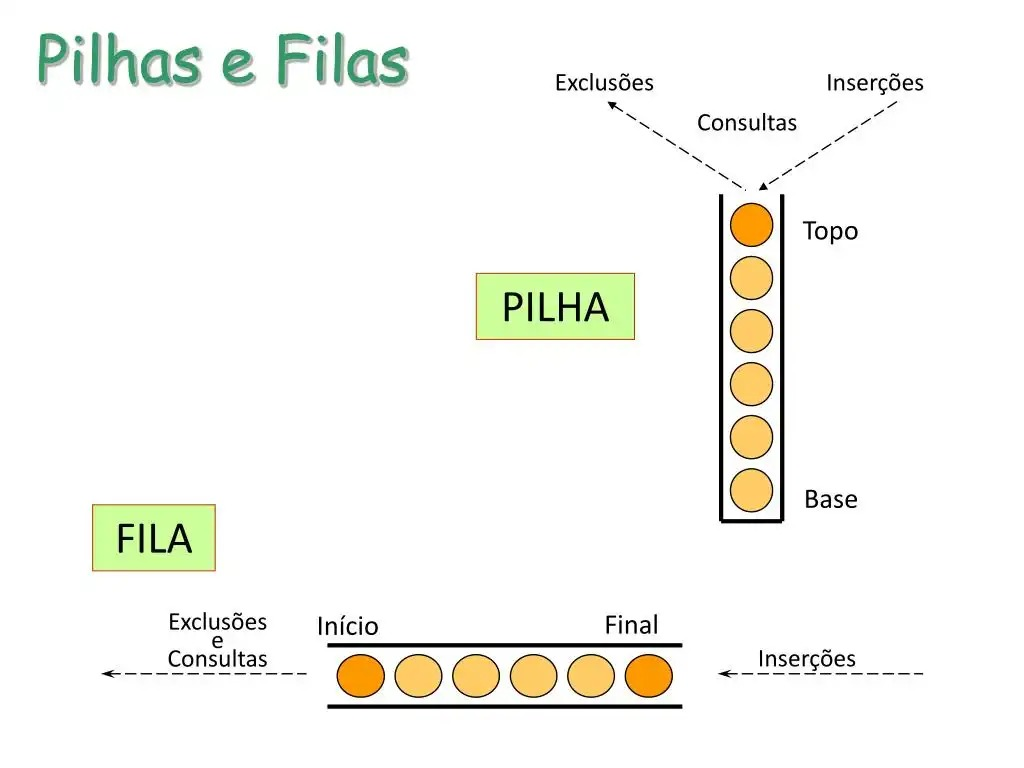

### **Implementação de filas**

In [66]:
class Queue:

    def __init__(self):
        self._queue = []

    def enqueue(self, value):

        self._queue.append(value)

    def dequeue(self):

        if not self.is_empty():

            return self._queue.pop(0)
        
        return None
    
    def is_empty(self):

        return len(self._queue) == 0
    
    def visualise(self):

        print('Fila atual: ')
        print(self._queue)

queue = Queue()

queue.enqueue(10)
queue.enqueue(9)
queue.enqueue(199)

queue.visualise()

print(queue.dequeue())
print(queue.dequeue())

queue.visualise()

Fila atual: 
[10, 9, 199]
10
9
Fila atual: 
[199]


## **Pesquisa em largura (BFS)**

`BFS` (Breadth-First Search) é um algoritmo de busca que investiga um grafo irradiando a partir de um vértice inicial por camadas de proximidade: primeiro visita todos os vizinhos diretos, depois os vizinhos dos vizinhos, e assim por diante.

Este algoritmo ajuda a responder a dois tipos de pergunta:

- Existe algum caminho do vértice A até o vértice B?

- Qual o **caminho mínimo** do vértice A até o vértice B?

### **Implementação pesquisa em largura**

In [ ]:
class BFS:

    def __init__(self, fila: Queue, grafo: dict):
        self.grafo = grafo
        self._visitados = set()
        self._pais = dict()
        self._fila = fila

    def pesquisar(self, no_inicial, destino):

        if no_inicial == destino:
            print(f"{destino} foi encontado!")
            return
        
        self._visitados.add(no_inicial)

        for vizinho in grafo[no_inicial]:
            self._fila.enqueue(vizinho)
            self._pais[vizinho] = no_inicial

        while not self._fila.is_empty():

            item = self._fila.dequeue()

            if item in self._visitados:
                continue

            if item == destino:
                print(f"{destino} foi encontado!")

                atual = destino
                caminho = []

                while not atual is None:
                    caminho.append(atual)
                    atual = self._pais.get(atual, None)

                return caminho[::-1]
            
            else:

                for vizinho in grafo.get(item,[]):
                    if vizinho not in self._visitados and vizinho not in self._pais:
                        self._fila.enqueue(vizinho)
                        self._pais[vizinho] = item

                self._visitados.add(item)       

        print(f'{destino} não faz parte do grafo!')
        return None  

In [68]:
fila = Queue()
pesquisa_em_largura = BFS(fila, grafo)

In [69]:
caminho = pesquisa_em_largura.pesquisar('guthy', 'peggy')

print(caminho)

peggy foi encontado!
['guthy', 'alice', 'peggy']


## **Recapitulando**

- A pesquisa em largura diz se há um caminho de A até B.

- Se esse caminho existir, a pesquisa em largura lhe dará o caminho mínimo.

- Um dígrafo contém setas e as relações seguem a direção das setas.

- Grafos não direcionados não contêm setas, e a relação acontece nos dois sentidos.

- Filas são FIFO (primeiro a entrar, primeiro a sair)

- Pilhas são LIFO (último a entrar, primeiro a sair)